In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
# df = pd.read_csv("data.csv")
df = pd.read_csv("data.csv", encoding='latin1')


In [19]:
# Show data
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [20]:
# Check null values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [21]:
# Basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

### DAta cleaning

In [22]:
# Remove missing values
df = df.dropna()

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [30]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10


### Analysis

1. Total Sales by Category

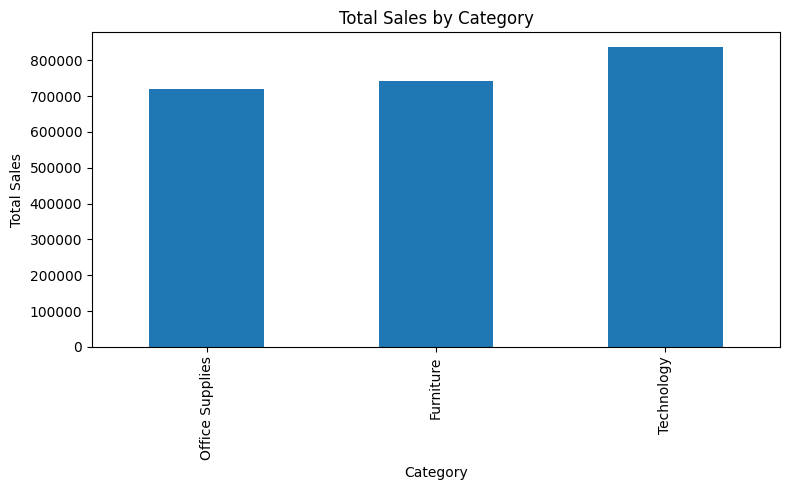

In [23]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values()

sales_by_category.plot(kind='bar', figsize=(8,5))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

**observation** : Technology category generates highest revenue”



2. Monthly Sales Trend

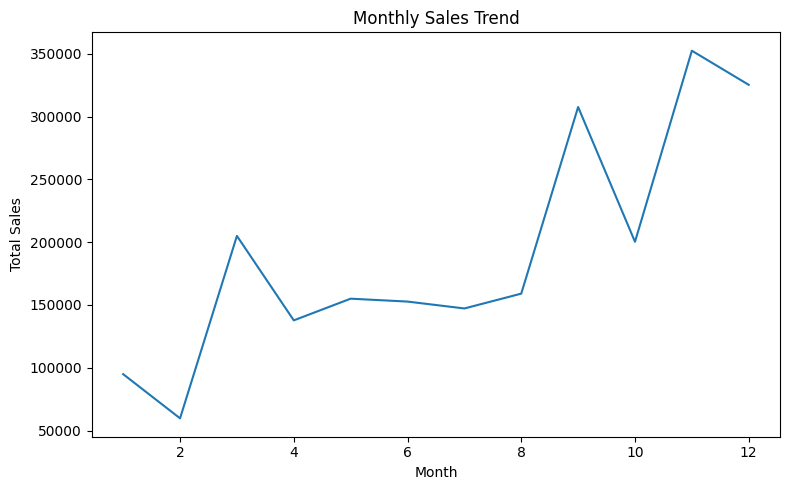

In [24]:
df['Month'] = df['Order Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(figsize=(8,5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

**observation** :“Sales peak during month X (seasonal trend)”

3. Top 10 Products

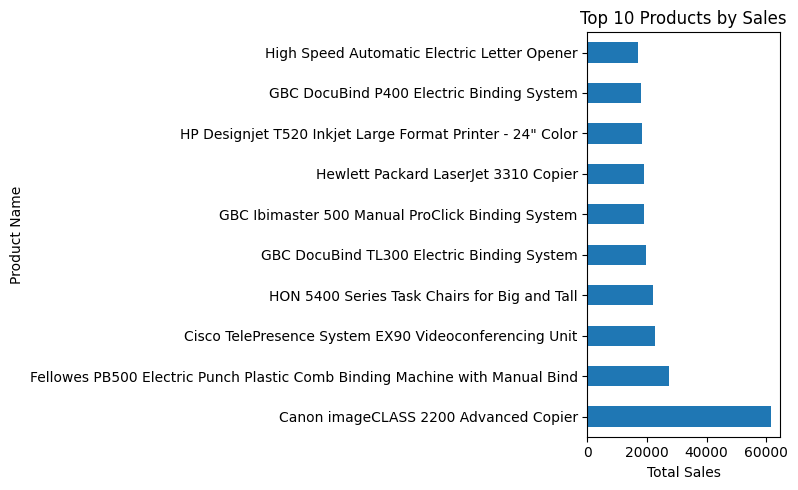

In [25]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)

top_products.plot(kind='barh', figsize=(8,5))

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

**observation** : “Certain products contribute majority of revenue”

4. Profit by Region

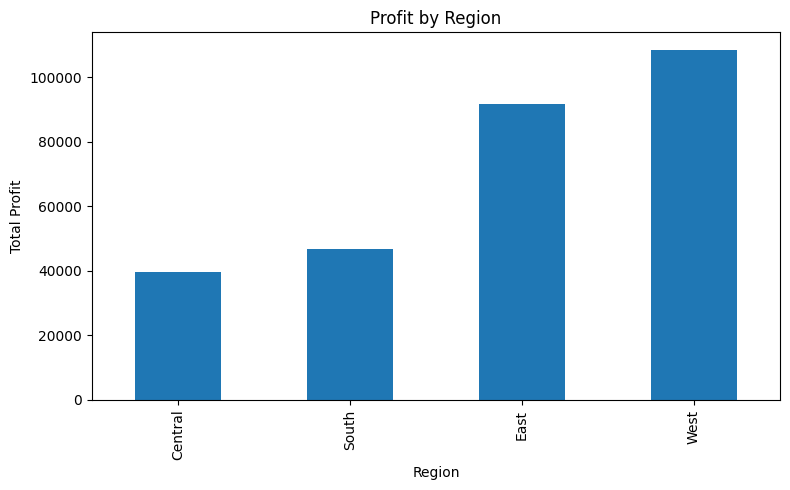

In [26]:
profit_region = df.groupby('Region')['Profit'].sum().sort_values()

profit_region.plot(kind='bar', figsize=(8,5))

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

**observation** : Profit varies significantly across regions, showing uneven business performance.

5. Loss-Making Products

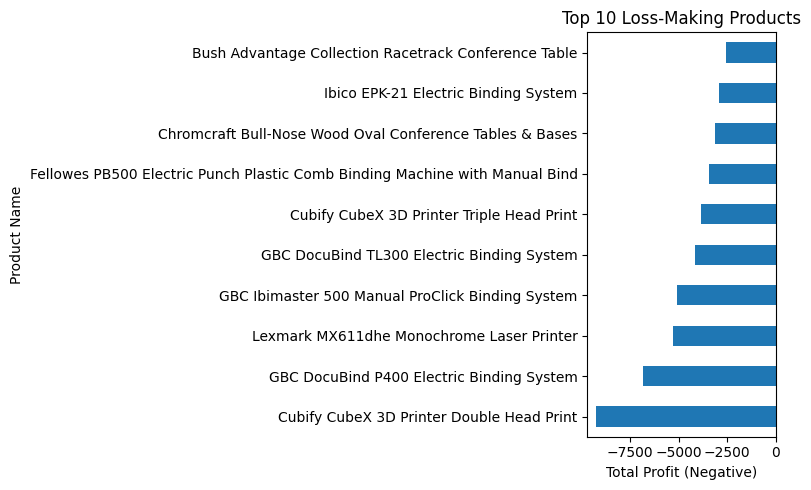

In [27]:
loss_products = df[df['Profit'] < 0]
loss_products = loss_products.groupby('Product Name')['Profit'].sum().nsmallest(10).sort_values()

loss_products.plot(kind='barh', figsize=(8,5))

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Total Profit (Negative)")
plt.ylabel("Product Name")

plt.tight_layout()
plt.show()

**observation** : A small number of products contribute significantly to overall losses.

6. Sales vs Profit

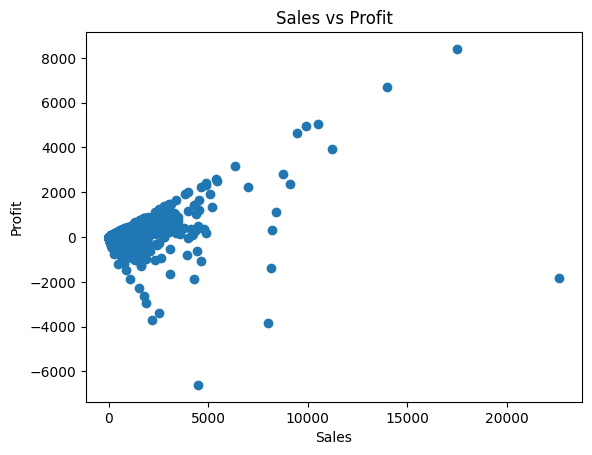

In [28]:
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Sales vs Profit")
plt.show()

**observation** : There is no direct linear relationship between sales and profit.

- Higher sales do not always result in higher profit.

7. Discount Impact

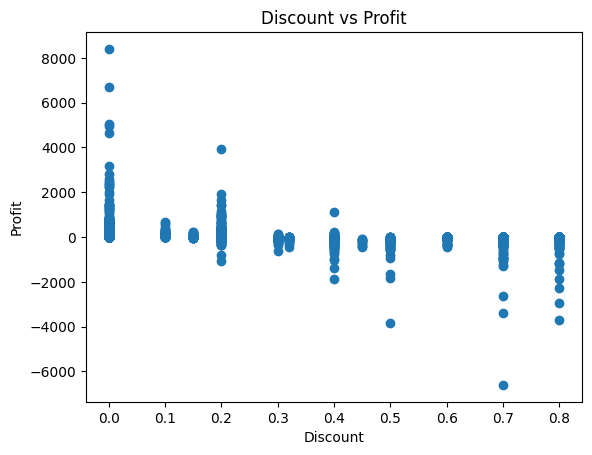

In [29]:
plt.scatter(df['Discount'], df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

**observation** : High discounts negatively impact profitability, often leading to losses, indicating the need for optimized pricing and controlled discount strategies.

## Conclusion

This analysis identified key factors affecting sales and profitability, including the negative impact of high discounts and the presence of loss-making products. Optimizing pricing strategies and focusing on high-performing products can significantly improve business performance.